In [471]:
import numpy as np

In [472]:
import mcstasscript as ms


In [473]:
configurator = ms.Configurator()
configurator.set_mcrun_path("/usr/bin/")
configurator.set_mcstas_path("/usr/share/mcstas/resources/")
print(configurator)

Configurator:
 paths:
  mcrun_path: /usr/bin/
  mcstas_path: /usr/share/mcstas/resources/
  mcxtrace_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/
  mxrun_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/bin/
 other:
  characters_per_line: 85



In [474]:
pip install pytest

Note: you may need to restart the kernel to use updated packages.


In [475]:
instrument = ms.McStas_instr("NSM_instrument")

In [476]:
instrument.available_components()

Here are the available component categories:
 contrib
 misc
 monitors
 obsolete
 optics
 samples
 sasmodels
 sources
 union
Call available_components(category_name) to display


In [477]:
instrument.available_components("sources")

Here are all components in the sources category.
 Adapt_check     Monitor_Optimizer   Source_adapt       Source_simple
 ESS_butterfly   Source_4PI          Source_div         
 ESS_moderator   Source_Maxwell_3    Source_div_quasi   
 Moderator       Source_Optimizer    Source_gen         


In [478]:
source = instrument.add_component("source", "Source_div")
source.show_parameters()

 ___ Help Source_div ________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xwidth [m] // Width of source
yheight [m] // Height of source
focus_aw [deg] // FWHM (Gaussian) or maximal (uniform) horz. width divergence
focus_ah [deg] // FWHM (Gaussian) or maximal (uniform) vert. height divergence
E0 = 0.0 [meV] // Mean energy of neutrons.
dE = 0.0 [meV] // Energy half spread of neutrons.
lambda0 = 0.0 [Ang] // Mean wavelength of neutrons (only relevant for E0=0)
dlambda = 0.0 [Ang] // Wavelength half spread of neutrons.
gauss = 0.0 [0|1] // Criterion
flux = 1.0 [1/(s cm 2 st energy_unit)] // flux per energy unit, Angs or meV
-------------------------------------------------------------------------------------


In [479]:
wavelength = instrument.add_parameter("wavelength", value=3, comment="Wavelength in AA")
source.lambda0 = wavelength
print(source)

COMPONENT source = Source_div(
  xwidth : Required parameter not yet specified
  yheight : Required parameter not yet specified
  focus_aw : Required parameter not yet specified
  focus_ah : Required parameter not yet specified
  lambda0 = wavelength // [Ang]
)
AT (0, 0, 0) ABSOLUTE


In [480]:
delta_wavelength = instrument.add_parameter("delta_wavelength", value=0.3, comment="delta_Wavelength in AA")
source.dlambda = "delta_wavelength"
print(source)

COMPONENT source = Source_div(
  xwidth : Required parameter not yet specified
  yheight : Required parameter not yet specified
  focus_aw : Required parameter not yet specified
  focus_ah : Required parameter not yet specified
  lambda0 = wavelength, // [Ang]
  dlambda = delta_wavelength // [Ang]
)
AT (0, 0, 0) ABSOLUTE


In [481]:
source.xwidth = 0.135
source.yheight = 0.08
#source.dist = 0.79045+0.39063
#source.T1 = 361.9
#source.I1 = 7.22e12 
#source.T2 = 159.0
#source.I2 = 6.74e12
#source.T3 = 35.66
#source.I3 = 6.435e12
source.focus_ah = 0.001
source.focus_aw = 0.001
#source.focus_xw = 0.0
#source.focus_yh = 0.0
print(source)

COMPONENT source = Source_div(
  xwidth = 0.135, // [m]
  yheight = 0.08, // [m]
  focus_aw = 0.001, // [deg]
  focus_ah = 0.001, // [deg]
  lambda0 = wavelength, // [Ang]
  dlambda = delta_wavelength // [Ang]
)
AT (0, 0, 0) ABSOLUTE


In [482]:
DIV= instrument.add_component("DIV", "Divergence_monitor")

In [483]:
DIV.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                   maxdiv_h= 4, maxdiv_v=5, nh =40, nv =40, restore_neutron=1)
DIV.set_AT([0, 0, 0.0001], RELATIVE=source)
print(DIV)

COMPONENT DIV = Divergence_monitor(
  nh = 40, // [1]
  nv = 40, // [1]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.15, // [m]
  ymax = 0.15, // [m]
  maxdiv_h = 4, // [degrees]
  maxdiv_v = 5, // [degrees]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.0001) RELATIVE source


In [484]:

PSD_1 = instrument.add_component("PSD_1", "PSD_monitor")
PSD_1.show_parameters()
PSD_1.set_AT([0, 0, 0.01], RELATIVE=source)

 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [485]:
PSD_1.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.10, ymax=0.10,nx=80,ny=200, filename='"PSD_1.dat"', restore_neutron=1)
print(PSD_1)

COMPONENT PSD_1 = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD_1.dat", // [string]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.1, // [m]
  ymax = 0.1, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.01) RELATIVE source


In [486]:
instrument.available_components("optics")

Here are all components in the optics category.
 Absorber                 Guide_channeled        Pol_FieldBox
 Arm                      Guide_gravity          Pol_SF_ideal
 Beamstop                 Guide_simple           Pol_bender
 Bender                   Guide_tapering         Pol_constBfield
 Collimator_linear        Guide_wavy             Pol_guide_mirror
 Collimator_radial        He3_cell               Pol_guide_vmirror
 Derotator                Mask                   Pol_mirror
 Diaphragm                Mirror                 Pol_tabled_field
 DiskChopper              Monochromator_curved   Refractor
 Elliptic_guide_gravity   Monochromator_flat     Rotator
 FZP_simple               Monochromator_pol      Selector
 FermiChopper             Place                  Set_pol
 Filter_gen               PolAnalyser_ideal      Slit
 Guide                    Pol_Bfield             V_selector
 Guide_anyshape           Pol_Bfield_stop        Vitess_ChopperFermi


In [487]:
NL_SR2_1= instrument.add_component("optics", "Guide_gravity")
NL_SR2_1.show_parameters()

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [488]:

NL_SR2_1.w1 = 0.105
NL_SR2_1.h1 = 0.098
NL_SR2_1.w2 = 0.105
NL_SR2_1.h2 = 0.118
NL_SR2_1.R0 = 0.995
NL_SR2_1.Qc = 0.02174
NL_SR2_1.l=1.307
NL_SR2_1.alpha = 4.38
NL_SR2_1.W = 0.0009
NL_SR2_1.nslit = 1
NL_SR2_1.mleft = 1.0
NL_SR2_1.mright = 1.0
NL_SR2_1.mtop = 1.0
NL_SR2_1.mbottom = 1.0

In [489]:
NL_SR2_1.set_AT([0, 0, 1.18108], RELATIVE=source)
print(NL_SR2_1)

COMPONENT optics = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.098, // [m]
  w2 = 0.105, // [m]
  h2 = 0.118, // [m]
  l = 1.307, // [m]
  R0 = 0.995, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 4.38, // [AA]
  W = 0.0009, // [AA-1]
  nslit = 1, // [1]
  mleft = 1.0, // [1]
  mright = 1.0, // [1]
  mtop = 1.0, // [1]
  mbottom = 1.0 // [1]
)
AT (0, 0, 1.18108) RELATIVE source


In [490]:
PSD = instrument.add_component("PSD", "PSD_monitor")
DIV1 = instrument.add_component("DIV1", "Divergence_monitor")
PSD.show_parameters()




 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [491]:
PSD.set_AT([0, 0, 1.18108++NL_SR2_1.l], RELATIVE=source)
DIV1.set_AT([0, 0, 1.18108++NL_SR2_1.l], RELATIVE=source)


In [492]:
print(PSD)
print(DIV1)

COMPONENT PSD = PSD_monitor(
)
AT (0, 0, 2.48808) RELATIVE source
COMPONENT DIV1 = Divergence_monitor(
)
AT (0, 0, 2.48808) RELATIVE source


In [493]:
PSD.set_parameters(xmin=-0.05, xmax=0.05, ymin=-0.11, ymax=0.11,nx=80,ny=200, filename='"PSD.dat"', restore_neutron=1)

DIV1.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                   maxdiv_h= 4, maxdiv_v=4, nh =40, nv =40, restore_neutron=1)

print(PSD)
print(DIV1)

COMPONENT PSD = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD.dat", // [string]
  xmin = -0.05, // [m]
  xmax = 0.05, // [m]
  ymin = -0.11, // [m]
  ymax = 0.11, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 2.48808) RELATIVE source
COMPONENT DIV1 = Divergence_monitor(
  nh = 40, // [1]
  nv = 40, // [1]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.15, // [m]
  ymax = 0.15, // [m]
  maxdiv_h = 4, // [degrees]
  maxdiv_v = 4, // [degrees]
  restore_neutron = 1 // [1]
)
AT (0, 0, 2.48808) RELATIVE source


In [494]:
instrument.show_parameters()

 wavelength        = 3    // Wavelength in AA
 delta_wavelength  = 0.3  // delta_Wavelength in AA


In [495]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x77da4b926760>, '_BaseCalculator__output_keys': ['NSM_instrument_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
wavelength                          3                               Wavelength in AA   
delta_wavelength                    0.3                             delta_Wavelength in AA   
, '_BaseCalculator__output': <libpyvinyl.BaseData.DataCollection object at 0x77da4b9274d0>, 'author': 'Python McStas Instrument Generator', 'origin': 'ESS DMSC', '_run_settings': {'executable_path': '/usr/bin', 'package_path': '/usr/share/mcstas/resources', 'run_path': '.', 'e

In [501]:
instrument.set_parameters(wavelength=4.8, delta_wavelength=0.01)
instrument.settings(ncount=2E6)
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_338"
INFO: Regenerating c-file: NSM_instrument.c
CFLAGS=
    
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
*** TRACE end *** 
Detector: DIV_I=3.89817e-10 DIV_ERR=3.58113e-13 DIV_N=1.1849e+06 "DIV.dat"
Detector: PSD_1_I=3.89817e-10 PSD_1_ERR=3.58113e-13 PSD_1_N=1.1849e+06 "PSD_1.dat"
Detector: PSD_I=4.87149e-10 PSD_ERR=4.00332e-13 PSD_N=1.48076e+06 "PSD.dat"
Detector: DIV1_I=3.89823e-10 DIV1_ERR=3.58115e-13 DIV1_N=1.18492e+06 "DIV1.dat"
INFO: Placing instr file copy NSM_instrument.instr 

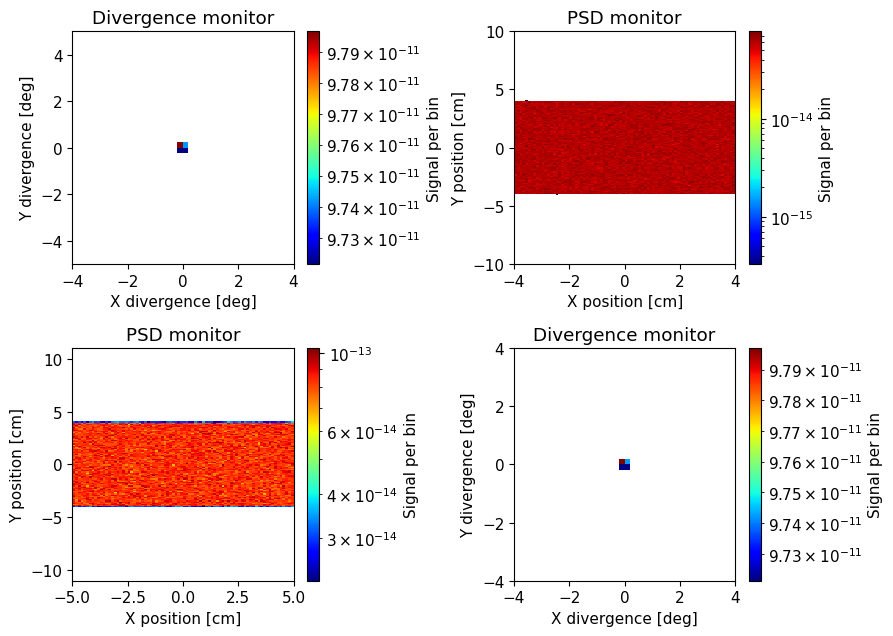

In [502]:
ms.make_sub_plot(data, log=True)

In [498]:
Intensity = []
wavelengths = []
all_data = []
for i in range(50):
    wl = 0.5 + i * 0.1
    instrument.set_parameters(wavelength=wl, delta_wavelength=0.01)
    instrument.settings(ncount=2E6)
    data = instrument.backengine()
    all_data.append(data)

print("Scan complete!")
 


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_336"
INFO: Regenerating c-file: NSM_instrument.c
CFLAGS=
    
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
*** TRACE end *** 
Detector: DIV_I=3.89895e-10 DIV_ERR=3.58149e-13 DIV_N=1.18514e+06 "DIV.dat"
Detector: PSD_1_I=3.89895e-10 PSD_1_ERR=3.58149e-13 PSD_1_N=1.18514e+06 "PSD_1.dat"
Detector: PSD_I=4.8753e-10 PSD_ERR=4.00488e-13 PSD_N=1.48191e+06 "PSD.dat"
Detector: DIV1_I=3.89906e-10 DIV1_ERR=3.58154e-13 DIV1_N=1.18517e+06 "DIV1.dat"
INFO: Placing instr file copy NSM_instrument.instr

KeyboardInterrupt: 

In [499]:
import matplotlib.pyplot as plt

In [ ]:
print(all_data)

[[
McStasData: DIV type: 2D  I:447929000.0 E:623010.0 N:534263.0, 
McStasData: PSD_1 type: 2D  I:999749000.0 E:929389.0 N:1196010.0, 
McStasData: PSD type: 2D  I:364132000.0 E:561705.0 N:434434.0, 
McStasData: DIV1 type: 2D  I:279111000.0 E:491864.0 N:332875.0], [
McStasData: DIV type: 2D  I:4395390000.0 E:6036790.0 N:534605.0, 
McStasData: PSD_1 type: 2D  I:9805360000.0 E:9003220.0 N:1196170.0, 
McStasData: PSD type: 2D  I:3563260000.0 E:5436010.0 N:433453.0, 
McStasData: DIV1 type: 2D  I:2730200000.0 E:4758780.0 N:332050.0], [
McStasData: DIV type: 2D  I:14097400000.0 E:19293900.0 N:535077.0, 
McStasData: PSD_1 type: 2D  I:31412300000.0 E:28757200.0 N:1195900.0, 
McStasData: PSD type: 2D  I:11452400000.0 E:17390300.0 N:434863.0, 
McStasData: DIV1 type: 2D  I:8768160000.0 E:15218100.0 N:332855.0], [
McStasData: DIV type: 2D  I:25826200000.0 E:35335200.0 N:534537.0, 
McStasData: PSD_1 type: 2D  I:57573400000.0 E:52680400.0 N:1195150.0, 
McStasData: PSD type: 2D  I:20927400000.0 E:31810

[279111000.0, 2730200000.0, 8768160000.0, 16030600000.0, 22102600000.0, 26289900000.0, 28642200000.0, 29645600000.0, 29406900000.0, 28266200000.0, 26593100000.0, 24548100000.0, 22372700000.0, 20268300000.0, 18326500000.0, 16705800000.0, 15370000000.0, 14213600000.0, 13385400000.0, 12701600000.0, 12106500000.0, 11720500000.0, 11266000000.0, 10944500000.0, 10599300000.0, 10297700000.0, 9911890000.0, 9553600000.0, 9215150000.0, 8856730000.0, 8461360000.0, 8089040000.0, 7704500000.0, 7348460000.0, 6979760000.0, 6620220000.0, 6276670000.0, 5915720000.0, 5587460000.0, 5278520000.0, 4986290000.0, 4691060000.0, 4431390000.0, 4163060000.0, 3911330000.0, 3688650000.0, 3470680000.0, 3262340000.0, 3069440000.0, 2885850000.0]
[0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0, 2.1, 2.2, 2.3, 2.4000000000000004, 2.5, 2.6, 2.7, 2.8000000000000003, 2.9000000000000004, 3.0, 3.1, 3.2, 3.3000000000000003, 3.4000000000000004, 3.5, 3

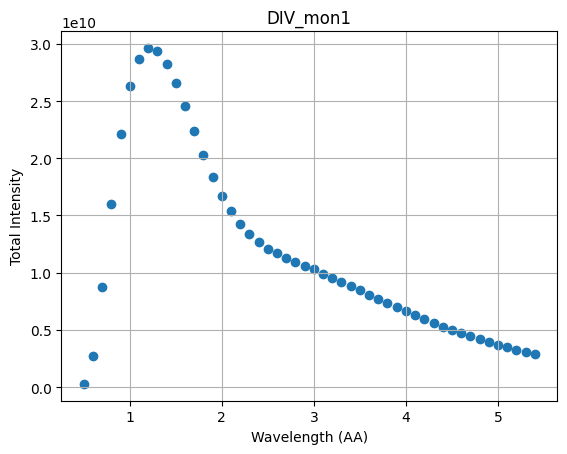

In [ ]:

DIV_mon1= []
wavelengths = []
for i in range(50):
    DIV_det_step= ms.name_search("DIV1", all_data[i])
    DIV_mon1.append(DIV_det_step.metadata.total_I)
    wavelengths.append(0.5 + i * 0.1)
print(DIV_mon1)
print(wavelengths)

plt.scatter(wavelengths, DIV_mon1)
plt.title("DIV_mon1")
plt.xlabel("Wavelength (AA)")
plt.ylabel("Total Intensity")
plt.grid()

In [504]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_339"
INFO: Regenerating c-file: NSM_instrument.c
CFLAGS=
    
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
*** TRACE end *** 
Detector: DIV_I=3.89848e-10 DIV_ERR=3.58127e-13 DIV_N=1.185e+06 "DIV.dat"
Detector: PSD_1_I=3.89848e-10 PSD_1_ERR=3.58127e-13 PSD_1_N=1.185e+06 "PSD_1.dat"
Detector: PSD_I=4.8759e-10 PSD_ERR=4.00513e-13 PSD_N=1.4821e+06 "PSD.dat"
Detector: DIV1_I=3.89848e-10 DIV1_ERR=3.58127e-13 DIV1_N=1.185e+06 "DIV1.dat"
INFO: Placing instr file copy NSM_instrument.instr in dat

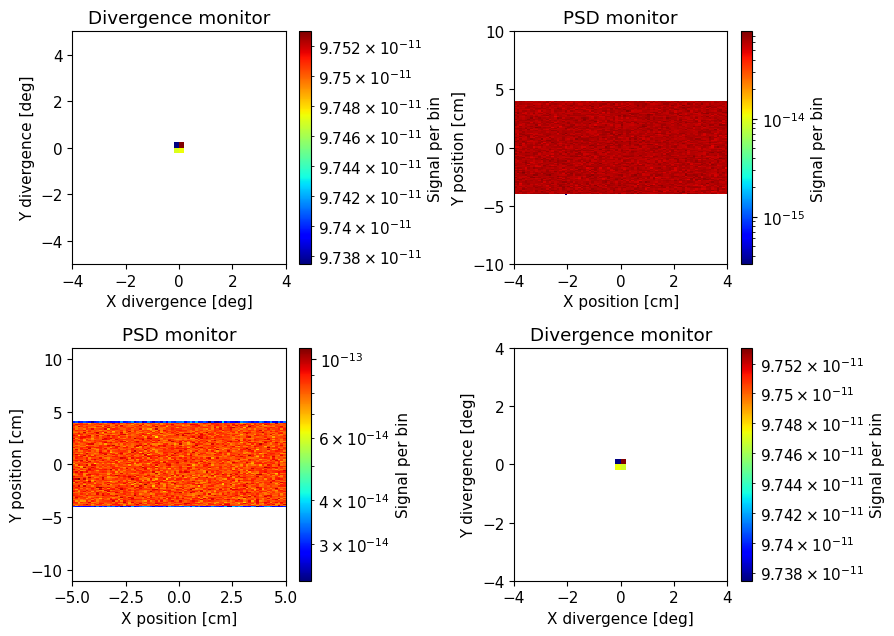

In [505]:
ms.make_sub_plot(data, log=True)

In [507]:
Intensity = []
Errors=[]
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 wavelength = 4.8
 delta_wavelength = 0.01



In [508]:
print(Intensity)
print(Errors)

[3.89848e-10]
[3.58127e-13]


In [509]:
NL_SR2_1.l=0.605
print(NL_SR2_1)

COMPONENT optics = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.098, // [m]
  w2 = 0.105, // [m]
  h2 = 0.118, // [m]
  l = 0.605, // [m]
  R0 = 0.995, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 4.38, // [AA]
  W = 0.0009, // [AA-1]
  nslit = 1, // [1]
  mleft = 1.0, // [1]
  mright = 1.0, // [1]
  mtop = 1.0, // [1]
  mbottom = 1.0 // [1]
)
AT (0, 0, 1.18108) RELATIVE source


In [511]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_341"
INFO: Regenerating c-file: NSM_instrument.c
CFLAGS=
    
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
*** TRACE end *** 
Detector: DIV_I=3.90489e-10 DIV_ERR=3.58421e-13 DIV_N=1.18694e+06 "DIV.dat"
Detector: PSD_1_I=3.90489e-10 PSD_1_ERR=3.58421e-13 PSD_1_N=1.18694e+06 "PSD_1.dat"
Detector: PSD_I=4.87683e-10 PSD_ERR=4.00551e-13 PSD_N=1.48238e+06 "PSD.dat"
Detector: DIV1_I=3.90487e-10 DIV1_ERR=3.5842e-13 DIV1_N=1.18694e+06 "DIV1.dat"
INFO: Placing instr file copy NSM_instrument.instr

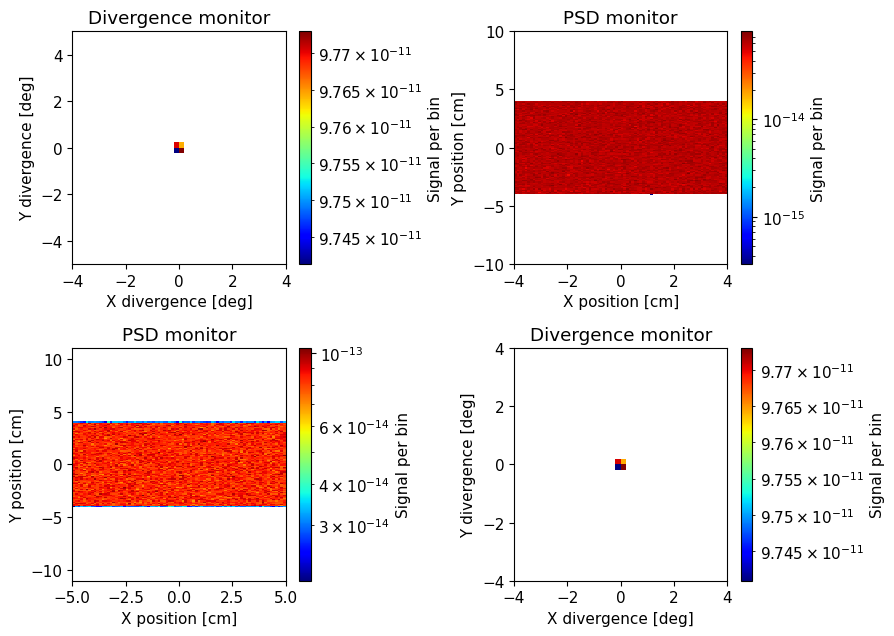

In [512]:
ms.make_sub_plot(data, log=True)

In [513]:
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 wavelength = 4.8
 delta_wavelength = 0.01



In [514]:
print(Intensity)
print(Errors)

[3.89848e-10, 3.90487e-10]
[3.58127e-13, 3.5842e-13]


In [515]:
NL_SR2_1.l=1.00

In [516]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_342"
INFO: Regenerating c-file: NSM_instrument.c
CFLAGS=
    
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
*** TRACE end *** 
Detector: DIV_I=3.90183e-10 DIV_ERR=3.58281e-13 DIV_N=1.18601e+06 "DIV.dat"
Detector: PSD_1_I=3.90183e-10 PSD_1_ERR=3.58281e-13 PSD_1_N=1.18601e+06 "PSD_1.dat"
Detector: PSD_I=4.87644e-10 PSD_ERR=4.00535e-13 PSD_N=1.48226e+06 "PSD.dat"
Detector: DIV1_I=3.90194e-10 DIV1_ERR=3.58286e-13 DIV1_N=1.18605e+06 "DIV1.dat"
INFO: Placing instr file copy NSM_instrument.inst

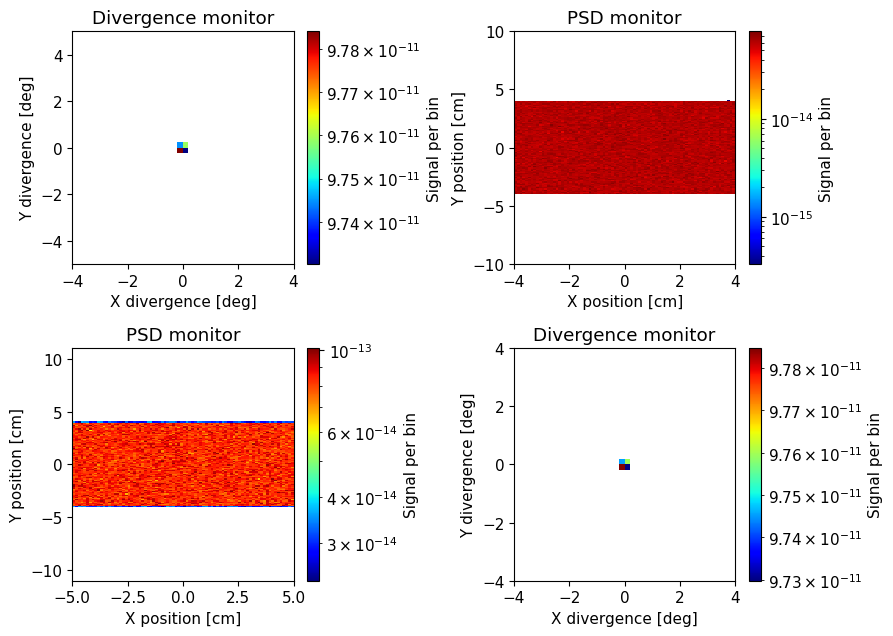

In [517]:
ms.make_sub_plot(data, log=True)

In [518]:
DIV1 = ms.name_search("DIV1", data)
print(DIV1.metadata)
Intensity.append(DIV1.metadata.total_I)
Errors.append(DIV1.metadata.total_E)
print(Intensity)
print(Errors)

metadata object
component_name: DIV1
filename: DIV1.dat
2D data of dimension (40, 40)
  [-4.0: 4.0] X divergence [deg]
  [-4.0: 4.0] Y divergence [deg]
 Signal per bin
Instrument parameters: 
 wavelength = 4.8
 delta_wavelength = 0.01

[3.89848e-10, 3.90487e-10, 3.90194e-10]
[3.58127e-13, 3.5842e-13, 3.58286e-13]


In [519]:
import matplotlib.pyplot as plt


/tmp/ipykernel_602/195076078.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


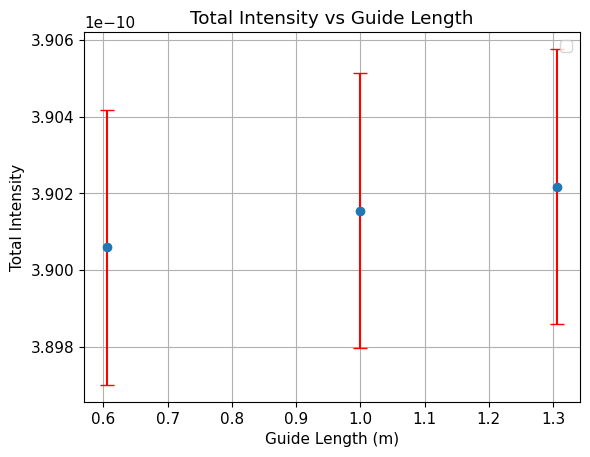

In [522]:


NL_SR2_1_lengths = np.array([1.307, 0.605, 1.00])


b, loga = coeffs
a = np.exp(loga)

plt.errorbar(NL_SR2_1_lengths, Intensity, yerr=Errors, fmt='o', ecolor='red', capsize=5, zorder=4)
plt.xlabel('Guide Length (m)')
plt.grid()
plt.ylabel('Total Intensity')
plt.title('Total Intensity vs Guide Length')
#plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x77da7f7350f0>, '_BaseCalculator__output_keys': ['NSM_instrument_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
wavelength                          5.4                             Wavelength in AA   
delta_wavelength                    0.01                            delta_Wavelength in AA   
, '_BaseCalculator__output': <libpyvinyl.BaseData.DataCollection object at 0x77da7f5056d0>, 'author': 'Python McStas Instrument Generator', 'origin': 'ESS DMSC', '_run_settings': {'executable_path': '/usr/bin', 'package_path': '/usr/share/mcstas/resources', 'run_path': '.', 'e

In [ ]:
NL_SR2_2a = instrument.add_component("NL_SR2_2a", "Guide_gravity")


In [ ]:
NL_SR2_2a.show_parameters()
NL_SR2_2a.set_AT([0, 0, 2.540], RELATIVE=source)
NL_SR2_2a.set_parameters(w1=0.106, h1=0.119,
                         w2=0.106, h2=0.134,
                         l=0.997, R0=0.99,
                         Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=3.0, mright=3.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [ ]:
NL_SR2_2_3 = instrument.add_component("NL_SR2_2_3", "Guide_gravity")


In [ ]:
NL_SR2_2_3.show_parameters()
NL_SR2_2_3.set_AT([0, 0, 3.546], RELATIVE=source)
NL_SR2_2_3.set_parameters(w1=0.107, h1=0.135,
                          w2=0.107, h2=0.138,
                          l=0.180, R0=0.99,
                          Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=2.0, mright=2.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [ ]:
SR2_Beamportwindow= instrument.add_component("SR2_Beamportwindow", "Al_window")


In [ ]:
SR2_Beamportwindow.show_parameters()
SR2_Beamportwindow.set_AT([0, 0, 3.81], RELATIVE=source)
SR2_Beamportwindow.set_parameters(thickness=0.003)

 ___ Help Al_window _________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
thickness = 0.001 [m] // Al Window thickness
-------------------------------------------------------------------------------------


In [ ]:
SR2_eob= instrument.add_component("SR2_eob", "Arm")

In [ ]:

SR2_eob.set_AT([0,0,0.0031], RELATIVE= 'SR2_Beamportwindow')
SR2_eob.set_ROTATED([0,0,0], RELATIVE= 'SR2_Beamportwindow')

In [ ]:
PANDA_ca1= instrument.add_component("PANDA_ca1", "Collimator_linear")

In [ ]:
PANDA_ca1.show_parameters()
PANDA_ca1.set_parameters(xwidth=0.108, yheight=0.160, divergence=80, length=0.50, transmission=1)
PANDA_ca1.set_AT([0,0,0.1000], RELATIVE= 'SR2_eob')

 ___ Help Collimator_linear _________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = -0.02 [m] // Lower x bound on slits
xmax = 0.02 [m] // Upper x bound on slits
ymin = -0.05 [m] // Lower y bound on slits
ymax = 0.05 [m] // Upper y bound on slits
xwidth = 0.0 [m] // Width of slits
yheight = 0.0 [m] // Height of slits
length = 0.3 [m] // Distance between input and output slits
divergence = 40.0 [minutes of arc] // Divergence horizontal angle (calculated 
                                      as atan(d/length), where d is the blade 
                                      spacing) 
transmission = 1.0 [1] // Transmission of Soller (0<=t<=1)
divergenceV = 0.0 [minutes of arc] // Divergence vertical angle
-------------------------------------------------------------------------------------


In [ ]:
PANDA_sapphire = instrument.add_component("PANDA_sapphire", "Filter_gen")
PANDA_sapphire.set_parameters(filename = "Al2O3_sapphire.trm", thickness = 0.86)
PANDA_sapphire.set_AT([0,0,0.9000], RELATIVE= 'SR2_eob')

In [ ]:
data = instrument.backengine()

---- Found 2 places in McStas output with keyword 'error'. 

./NSM_instrument.c:10625:6: error: ‘Al2O3_sapphire’ undeclared (first use in this function)
10625 |   if(Al2O3_sapphire . trm && strlen(Al2O3_sapphire . trm))
      |      ^~~~~~~~~~~~~~
./NSM_instrument.c:10625:6: note: each undeclared identifier is reported only once for each function it appears in
INFO: call to gcc failed with Command 'gcc -o ./NSM_instrument.out ./NSM_instrument.c -lm -fno-PIC -fPIE -flto -O3 -mtune=native -march=native -fno-math-errno -ftree-vectorize -g -DNDEBUG -D_POSIX_SOURCE -std=c99 -lm' returned non-zero exit status 1.
----------------------------------------------------------------------
ERROR: Compilation failed for ./NSM_instrument.c using compiler gcc

----------------------------------------------------------------------

INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_247"
INFO: Regenerating c-file: NSM_instrument.c
Info:    'Al_window' is a contributed compo

/home/sierra_manrique/miniforge3/lib/python3.13/site-packages/mcstasscript/helper/managed_mcrun.py:302: UserWarning: Simulation did not create data folder, most likely failed.
  warnings.warn("Simulation did not create data folder, most likely failed.")
/home/sierra_manrique/miniforge3/lib/python3.13/site-packages/mcstasscript/helper/managed_mcrun.py:332: UserWarning: No data available to load.
  warnings.warn("No data available to load.")
